In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules, fpgrowth

In [12]:
df = pd.read_excel("Bird_Migration_Data_with _names_and_origin.xlsx")

df.head()

,Bird_ID,Bird_Name,Species,Region,Habitat,Weather_Condition,Migration_Reason,Start_Latitude,Start_Longitude,End_Latitude,...,Migration_Interrupted,Interrupted_Reason,Tagged_By,Tag_Weight_g,Migration_Success,Recovery_Location_Known,Recovery_Time_days,Observation_Counts,Observation_Quality,Origin
0,B1000,Yellow Warbler,Warbler,South America,Grassland,Stormy,Feeding,11.906566,-169.378251,30.377647,...,Yes,Storm,Researcher_A,27.0,Failed,No,102,56,Low,"11.906566441337574, -169.37825068830264"
1,B1001,White Stork,Stork,North America,Grassland,Stormy,Breeding,62.301546,-111.475069,39.921092,...,Yes,Injury,Researcher_C,14.2,Successful,Yes,118,61,Low,"62.301545854189925, -111.47506945435978"
2,B1002,Red-tailed Hawk,Hawk,South America,Mountain,Stormy,Avoid Predators,87.861164,-78.727327,66.990980,...,No,Lost Signal,Researcher_B,16.1,Failed,No,41,71,High,"87.86116387126651, -78.72732718179907"
3,B1003,Blackpoll Warbler,Warbler,South America,Urban,Stormy,Climate Change,35.770590,153.104341,-49.003145,...,Yes,Lost Signal,Researcher_C,24.4,Successful,No,15,68,Low,"35.77058955392532, 153.1043405316318"
4,B1004,Common Crane,Crane,Europe,Urban,Windy,Avoid Predators,-21.611614,106.674824,11.681051,...,No,NaN,Researcher_B,25.8,Failed,Yes,73,67,Moderate,"-21.611614380025586, 106.67482429343966"


In [13]:
selected_cols = ['Bird_Name', 'Origin', 
                 'Flight_Distance_km', 'Flight_Duration_hours']

bird_subset = df[selected_cols]

print("Selected Data:")
print(bird_subset.head())

Selected Data:
           Bird_Name                                   Origin  \
0     Yellow Warbler  11.906566441337574, -169.37825068830264   
1        White Stork  62.301545854189925, -111.47506945435978   
2    Red-tailed Hawk    87.86116387126651, -78.72732718179907   
3  Blackpoll Warbler     35.77058955392532, 153.1043405316318   
4       Common Crane  -21.611614380025586, 106.67482429343966   

   Flight_Distance_km  Flight_Duration_hours  
0             1753.79                   49.5  
1             3263.05                   46.1  
2             2871.65                   30.2  
3             2317.38                   58.7  
4             3077.38                   56.9  


In [14]:
bird_subset['Flight_Distance_km'] = pd.to_numeric(
    bird_subset['Flight_Distance_km'], 
    errors='coerce'
)

bird_subset['Flight_Duration_hours'] = pd.to_numeric(
    bird_subset['Flight_Duration_hours'], 
    errors='coerce'
)
bird_subset[['Flight_Distance_km', 
             'Flight_Duration_hours']] = \
bird_subset[['Flight_Distance_km', 
             'Flight_Duration_hours']].ffill()

In [15]:
bird_subset['Distance_Binned'] = pd.cut(
    bird_subset['Flight_Distance_km'], bins=4)

bird_subset['Duration_Binned'] = pd.cut(
    bird_subset['Flight_Duration_hours'], bins=4)

In [16]:
final_data = bird_subset[['Bird_Name', 
                          'Origin', 
                          'Distance_Binned', 
                          'Duration_Binned']]

In [17]:
encoded_data = pd.get_dummies(final_data)

In [18]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

fp_itemsets = fpgrowth(encoded_data, 
                       min_support=0.02, 
                       use_colnames=True)

rules = association_rules(fp_itemsets, 
                          metric="confidence", 
                          min_threshold=0.3)

print(rules.sort_values('lift', ascending=False).head())

                                        antecedents  \
3  frozenset({Distance_Binned_(2478.01, 3453.165]})   
2         frozenset({Duration_Binned_(32.2, 51.8]})   
5  frozenset({Distance_Binned_(1502.855, 2478.01]})   
4         frozenset({Duration_Binned_(51.8, 71.4]})   
0         frozenset({Duration_Binned_(32.2, 51.8]})   

                                        consequents  antecedent support  \
3         frozenset({Duration_Binned_(32.2, 51.8]})              0.4970   
2  frozenset({Distance_Binned_(2478.01, 3453.165]})              0.5300   
5         frozenset({Duration_Binned_(51.8, 71.4]})              0.4501   
4  frozenset({Distance_Binned_(1502.855, 2478.01]})              0.4146   
0  frozenset({Distance_Binned_(1502.855, 2478.01]})              0.5300   

   consequent support  support  confidence      lift  representativity  \
3              0.5300   0.2654    0.534004  1.007555               1.0   
2              0.4970   0.2654    0.500755  1.007555               1.0

In [20]:
from mlxtend.frequent_patterns import association_rules

frequent_itemsets = apriori(
    encoded_data,
    min_support=0.01,   # reduce support
    use_colnames=True
)

rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.2   # reduce confidence
)
# Step 1: Check if frequent itemsets exist
if frequent_itemsets.empty:
    print("No frequent itemsets found. Try reducing min_support.")
else:
    
    # Step 2: Generate rules
    rules = association_rules(
        frequent_itemsets,
        metric="confidence",
        min_threshold=0.3
    )
    
    # Step 3: Check if rules exist
    if rules.empty:
        print("No rules generated. Try reducing min_threshold.")
    else:
        
        # Step 4: Convert frozenset to readable format
        rules['antecedents'] = rules['antecedents'].apply(lambda x: ', '.join(list(x)))
        rules['consequents'] = rules['consequents'].apply(lambda x: ', '.join(list(x)))
        
        # Step 5: Sort and print top rules
        print("All Generated Rules (Top 5 Sorted by Lift):")
        print(rules.sort_values('lift', ascending=False).head())
        
        print("\nTotal Rules Generated:", len(rules))

All Generated Rules (Top 5 Sorted by Lift):
                            antecedents                          consequents  \
2        Duration_Binned_(12.522, 32.2]  Distance_Binned_(1502.855, 2478.01]   
1   Distance_Binned_(523.799, 1502.855]         Duration_Binned_(51.8, 71.4]   
13  Distance_Binned_(3453.165, 4428.32]         Duration_Binned_(51.8, 71.4]   
12  Distance_Binned_(3453.165, 4428.32]         Duration_Binned_(32.2, 51.8]   
8          Duration_Binned_(32.2, 51.8]  Distance_Binned_(2478.01, 3453.165]   

    antecedent support  consequent support  support  confidence      lift  \
2               0.0402              0.4501   0.0190    0.472637  1.050071   
1               0.0247              0.4146   0.0107    0.433198  1.044859   
13              0.0282              0.4146   0.0122    0.432624  1.043474   
12              0.0282              0.5300   0.0152    0.539007  1.016995   
8               0.5300              0.4970   0.2654    0.500755  1.007555   

    represen

In [21]:
high_conf_rules = rules[rules['confidence'] >= 0.60]

print("Number of rules with confidence ≥ 60%:", len(high_conf_rules))

Number of rules with confidence ≥ 60%: 0


In [22]:
print(high_conf_rules.sort_values('lift', ascending=False))

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


In [23]:
total_transactions = len(encoded_data)
rules['support_count'] = rules['support'] * total_transactions
rules_support_gt2 = rules[rules['support_count'] > 2]

print("Rules with support count > 2:", len(rules_support_gt2))

Rules with support count > 2: 14


In [24]:
filtered_rules = rules[
    (rules['confidence'] >= 0.60) &
    (rules['support_count'] > 2)
]

print("Rules with confidence ≥ 60% and support count > 2:")
print(filtered_rules.sort_values('lift', ascending=False))
print("Total:", len(filtered_rules))

Rules with confidence ≥ 60% and support count > 2:
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski, support_count]
Index: []
Total: 0


FP-Growth:-


In [25]:
from mlxtend.frequent_patterns import fpgrowth, association_rules

fp_itemsets = fpgrowth(
    encoded_data,
    min_support=0.02,
    use_colnames=True
)

print("Number of Frequent Itemsets:", len(fp_itemsets))

Number of Frequent Itemsets: 11


In [26]:
fp_rules = association_rules(
    fp_itemsets,
    metric="confidence",
    min_threshold=0.3
)

print("Total Rules Generated:", len(fp_rules))

Total Rules Generated: 8


In [27]:
print("Top Rules Sorted by Lift:")
print(fp_rules.sort_values('lift', ascending=False).head(10))

Top Rules Sorted by Lift:
                                        antecedents  \
3  frozenset({Distance_Binned_(2478.01, 3453.165]})   
2         frozenset({Duration_Binned_(32.2, 51.8]})   
5  frozenset({Distance_Binned_(1502.855, 2478.01]})   
4         frozenset({Duration_Binned_(51.8, 71.4]})   
0         frozenset({Duration_Binned_(32.2, 51.8]})   
1  frozenset({Distance_Binned_(1502.855, 2478.01]})   
6         frozenset({Duration_Binned_(51.8, 71.4]})   
7  frozenset({Distance_Binned_(2478.01, 3453.165]})   

                                        consequents  antecedent support  \
3         frozenset({Duration_Binned_(32.2, 51.8]})              0.4970   
2  frozenset({Distance_Binned_(2478.01, 3453.165]})              0.5300   
5         frozenset({Duration_Binned_(51.8, 71.4]})              0.4501   
4  frozenset({Distance_Binned_(1502.855, 2478.01]})              0.4146   
0  frozenset({Distance_Binned_(1502.855, 2478.01]})              0.5300   
1         frozenset({Duratio

In [28]:
total_transactions = len(encoded_data)

fp_rules['support_count'] = fp_rules['support'] * total_transactions

In [29]:
high_conf_fp = fp_rules[fp_rules['confidence'] >= 0.60]

print("Rules with confidence ≥ 60%:", len(high_conf_fp))
print(high_conf_fp.sort_values('lift', ascending=False))

Rules with confidence ≥ 60%: 0
Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski, support_count]
Index: []


In [30]:
support_gt2_fp = fp_rules[fp_rules['support_count'] > 2]

print("Rules with support count > 2:", len(support_gt2_fp))

Rules with support count > 2: 8


In [31]:
filtered_fp_rules = fp_rules[
    (fp_rules['confidence'] >= 0.30) &
    (fp_rules['support_count'] > 2)
]

print("Strong FP-Growth Rules:")
print(filtered_fp_rules.sort_values('lift', ascending=False))
print("Total Strong Rules:", len(filtered_fp_rules))

Strong FP-Growth Rules:
                                        antecedents  \
3  frozenset({Distance_Binned_(2478.01, 3453.165]})   
2         frozenset({Duration_Binned_(32.2, 51.8]})   
5  frozenset({Distance_Binned_(1502.855, 2478.01]})   
4         frozenset({Duration_Binned_(51.8, 71.4]})   
0         frozenset({Duration_Binned_(32.2, 51.8]})   
1  frozenset({Distance_Binned_(1502.855, 2478.01]})   
6         frozenset({Duration_Binned_(51.8, 71.4]})   
7  frozenset({Distance_Binned_(2478.01, 3453.165]})   

                                        consequents  antecedent support  \
3         frozenset({Duration_Binned_(32.2, 51.8]})              0.4970   
2  frozenset({Distance_Binned_(2478.01, 3453.165]})              0.5300   
5         frozenset({Duration_Binned_(51.8, 71.4]})              0.4501   
4  frozenset({Distance_Binned_(1502.855, 2478.01]})              0.4146   
0  frozenset({Distance_Binned_(1502.855, 2478.01]})              0.5300   
1         frozenset({Duration_

FP TREE


In [32]:
transactions = []

for _, row in encoded_data.iterrows():
    transaction = list(row[row == 1].index)
    transactions.append(transaction)

# Use only first 10 transactions for tree visualization
transactions_sample = transactions[:10]

print(transactions_sample)

[['Bird_Name_Yellow Warbler', 'Origin_11.906566441337574, -169.37825068830264', 'Distance_Binned_(1502.855, 2478.01]', 'Duration_Binned_(32.2, 51.8]'], ['Bird_Name_White Stork', 'Origin_62.301545854189925, -111.47506945435978', 'Distance_Binned_(2478.01, 3453.165]', 'Duration_Binned_(32.2, 51.8]'], ['Bird_Name_Red-tailed Hawk', 'Origin_87.86116387126651, -78.72732718179907', 'Distance_Binned_(2478.01, 3453.165]', 'Duration_Binned_(12.522, 32.2]'], ['Bird_Name_Blackpoll Warbler', 'Origin_35.77058955392532, 153.1043405316318', 'Distance_Binned_(1502.855, 2478.01]', 'Duration_Binned_(51.8, 71.4]'], ['Bird_Name_Common Crane', 'Origin_-21.611614380025586, 106.67482429343966', 'Distance_Binned_(2478.01, 3453.165]', 'Duration_Binned_(51.8, 71.4]'], ["Bird_Name_Cooper's Hawk", 'Origin_-15.8716165438901, 138.29223115055436', 'Distance_Binned_(2478.01, 3453.165]', 'Duration_Binned_(51.8, 71.4]'], ['Bird_Name_Sharp-shinned Hawk', 'Origin_-26.697200446302496, -21.42750701617652', 'Distance_Binned_

In [33]:
class FPNode:
    def __init__(self, item, count=1):
        self.item = item
        self.count = count
        self.children = {}

In [34]:
def insert_tree(transaction, node):
    if len(transaction) == 0:
        return
    
    first_item = transaction[0]
    
    if first_item in node.children:
        node.children[first_item].count += 1
    else:
        node.children[first_item] = FPNode(first_item)
    
    insert_tree(transaction[1:], node.children[first_item])

# Create root
root = FPNode("Null")

for transaction in transactions_sample:
    insert_tree(transaction, root)

Printing FP TREE:-

In [35]:
def print_tree(node, indent=0):
    print("  " * indent + f"{node.item}: {node.count}")
    for child in node.children.values():
        print_tree(child, indent + 1)

print_tree(root)

Null: 1
  Bird_Name_Yellow Warbler: 1
    Origin_11.906566441337574, -169.37825068830264: 1
      Distance_Binned_(1502.855, 2478.01]: 1
        Duration_Binned_(32.2, 51.8]: 1
  Bird_Name_White Stork: 1
    Origin_62.301545854189925, -111.47506945435978: 1
      Distance_Binned_(2478.01, 3453.165]: 1
        Duration_Binned_(32.2, 51.8]: 1
  Bird_Name_Red-tailed Hawk: 1
    Origin_87.86116387126651, -78.72732718179907: 1
      Distance_Binned_(2478.01, 3453.165]: 1
        Duration_Binned_(12.522, 32.2]: 1
  Bird_Name_Blackpoll Warbler: 1
    Origin_35.77058955392532, 153.1043405316318: 1
      Distance_Binned_(1502.855, 2478.01]: 1
        Duration_Binned_(51.8, 71.4]: 1
  Bird_Name_Common Crane: 1
    Origin_-21.611614380025586, 106.67482429343966: 1
      Distance_Binned_(2478.01, 3453.165]: 1
        Duration_Binned_(51.8, 71.4]: 1
  Bird_Name_Cooper's Hawk: 1
    Origin_-15.8716165438901, 138.29223115055436: 1
      Distance_Binned_(2478.01, 3453.165]: 1
        Duration_Binned_(

visualizing

In [36]:
rules   # from apriori

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,support_count
0,"Distance_Binned_(523.799, 1502.855]","Duration_Binned_(32.2, 51.8]",0.0247,0.5300,0.0128,0.518219,0.977771,1.0,-0.000291,0.975546,-0.022779,0.023621,-0.025067,0.271185,128.0
1,"Distance_Binned_(523.799, 1502.855]","Duration_Binned_(51.8, 71.4]",0.0247,0.4146,0.0107,0.433198,1.044859,1.0,0.000459,1.032813,0.044020,0.024965,0.031770,0.229503,107.0
2,"Duration_Binned_(12.522, 32.2]","Distance_Binned_(1502.855, 2478.01]",0.0402,0.4501,0.0190,0.472637,1.050071,1.0,0.000906,1.042735,0.049680,0.040314,0.040983,0.257425,190.0
3,"Duration_Binned_(32.2, 51.8]","Distance_Binned_(1502.855, 2478.01]",0.5300,0.4501,0.2366,0.446415,0.991813,1.0,-0.001953,0.993344,-0.017260,0.318225,-0.006701,0.486038,2366.0
4,"Distance_Binned_(1502.855, 2478.01]","Duration_Binned_(32.2, 51.8]",0.4501,0.5300,0.2366,0.525661,0.991813,1.0,-0.001953,0.990852,-0.014789,0.318225,-0.009232,0.486038,2366.0
5,"Duration_Binned_(51.8, 71.4]","Distance_Binned_(1502.855, 2478.01]",0.4146,0.4501,0.1874,0.452002,1.004226,1.0,0.000789,1.003471,0.007188,0.276687,0.003459,0.434177,1874.0
6,"Distance_Binned_(1502.855, 2478.01]","Duration_Binned_(51.8, 71.4]",0.4501,0.4146,0.1874,0.416352,1.004226,1.0,0.000789,1.003002,0.007652,0.276687,0.002993,0.434177,1874.0
7,"Duration_Binned_(12.522, 32.2]","Distance_Binned_(2478.01, 3453.165]",0.0402,0.4970,0.0197,0.490050,0.986016,1.0,-0.000279,0.986371,-0.014562,0.038068,-0.013818,0.264844,197.0
8,"Duration_Binned_(32.2, 51.8]","Distance_Binned_(2478.01, 3453.165]",0.5300,0.4970,0.2654,0.500755,1.007555,1.0,0.001990,1.007521,0.015953,0.348477,0.007465,0.517379,2654.0
9,"Distance_Binned_(2478.01, 3453.165]","Duration_Binned_(32.2, 51.8]",0.4970,0.5300,0.2654,0.534004,1.007555,1.0,0.001990,1.008592,0.014907,0.348477,0.008519,0.517379,2654.0


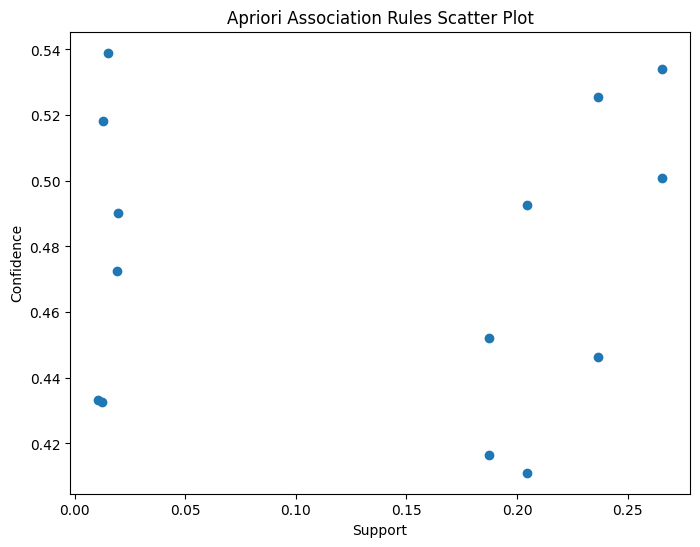

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(rules['support'], rules['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Apriori Association Rules Scatter Plot")

plt.show()

In [38]:
fp_rules   # from fpgrowth

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski,support_count
0,"frozenset({Duration_Binned_(32.2, 51.8]})","frozenset({Distance_Binned_(1502.855, 2478.01]})",0.5300,0.4501,0.2366,0.446415,0.991813,1.0,-0.001953,0.993344,-0.017260,0.318225,-0.006701,0.486038,2366.0
1,"frozenset({Distance_Binned_(1502.855, 2478.01]})","frozenset({Duration_Binned_(32.2, 51.8]})",0.4501,0.5300,0.2366,0.525661,0.991813,1.0,-0.001953,0.990852,-0.014789,0.318225,-0.009232,0.486038,2366.0
2,"frozenset({Duration_Binned_(32.2, 51.8]})","frozenset({Distance_Binned_(2478.01, 3453.165]})",0.5300,0.4970,0.2654,0.500755,1.007555,1.0,0.001990,1.007521,0.015953,0.348477,0.007465,0.517379,2654.0
3,"frozenset({Distance_Binned_(2478.01, 3453.165]})","frozenset({Duration_Binned_(32.2, 51.8]})",0.4970,0.5300,0.2654,0.534004,1.007555,1.0,0.001990,1.008592,0.014907,0.348477,0.008519,0.517379,2654.0
4,"frozenset({Duration_Binned_(51.8, 71.4]})","frozenset({Distance_Binned_(1502.855, 2478.01]})",0.4146,0.4501,0.1874,0.452002,1.004226,1.0,0.000789,1.003471,0.007188,0.276687,0.003459,0.434177,1874.0
5,"frozenset({Distance_Binned_(1502.855, 2478.01]})","frozenset({Duration_Binned_(51.8, 71.4]})",0.4501,0.4146,0.1874,0.416352,1.004226,1.0,0.000789,1.003002,0.007652,0.276687,0.002993,0.434177,1874.0
6,"frozenset({Duration_Binned_(51.8, 71.4]})","frozenset({Distance_Binned_(2478.01, 3453.165]})",0.4146,0.4970,0.2043,0.492764,0.991477,1.0,-0.001756,0.991649,-0.014472,0.288845,-0.008421,0.451915,2043.0
7,"frozenset({Distance_Binned_(2478.01, 3453.165]})","frozenset({Duration_Binned_(51.8, 71.4]})",0.4970,0.4146,0.2043,0.411066,0.991477,1.0,-0.001756,0.994000,-0.016803,0.288845,-0.006036,0.451915,2043.0


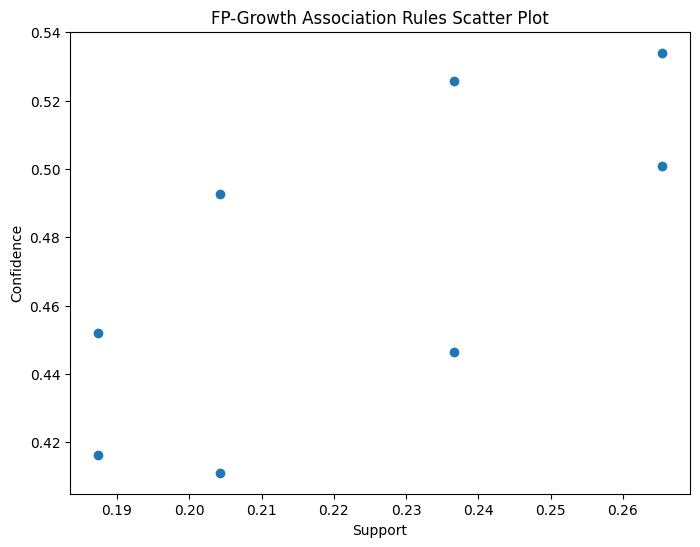

In [39]:
plt.figure(figsize=(8,6))
plt.scatter(fp_rules['support'], fp_rules['confidence'])

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("FP-Growth Association Rules Scatter Plot")

plt.show()